# Modelo de Kuramoto en redes modulares

Este cuaderno extiende el modelo de Kuramoto del cuaderno anterior, pero ahora los osciladores ya no están todos conectados con todos: viven sobre una red estructurada en **módulos**. Cada módulo está densamente conectado por dentro, pero los enlaces entre módulos son escasos. El objetivo es estudiar cómo aparece la sincronización local antes que la global y cómo emerge un régimen metaestable como consecuencia de la frustración estructural.

La ecuación general del modelo en una red es:

$$\dot{\theta}_i = \omega_i + K \sum_{j=1}^N A_{ij} \sin(\theta_j - \theta_i)$$

donde $A_{ij} \in \{0, 1\}$ es la matriz de adyacencia: vale 1 si los osciladores $i$ y $j$ están conectados, 0 en caso contrario. La matriz es simétrica ($A_{ij} = A_{ji}$, red no dirigida) y con diagonal nula (sin auto-conexiones).

**Diferencia clave con el caso mean-field:** en el cuaderno anterior podíamos colapsar la suma usando el atajo $K \cdot R \cdot \sin(\psi - \theta_i)$, porque cada oscilador "veía" el mismo parámetro de orden global. Aquí no: cada oscilador percibe un campo local distinto, así que hay que sumar explícitamente sobre sus vecinos. Esto cambia el coste por paso de $O(N)$ a $O(N^2)$.

Además del parámetro de orden global $R(t)$, definimos el parámetro de orden por módulo:

$$r_m(t) \, e^{i\psi_m(t)} = \frac{1}{|m|} \sum_{j \in m} e^{i\theta_j(t)}$$

donde $|m|$ es el número de osciladores del módulo $m$. La firma de la frustración estructural es: los $r_m(t)$ se acercan a 1 (cada módulo coherente internamente) mientras que $R(t)$ permanece bajo o fluctúa, porque las fases medias $\psi_m$ de los distintos módulos no están alineadas entre sí.

In [1]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
from joblib import Parallel, delayed

## Configuración del estilo y paths

Reutilizamos la función `setup_plot_style` del cuaderno anterior para mantener un estilo homogéneo. El path apunta a una subcarpeta `Tarea2` dentro del directorio `figures` para no mezclar los resultados de las dos tareas.

In [2]:
def setup_plot_style():
    """Configura matplotlib con estilo profesional para publicaciones."""
    plt.rcParams.update({
        'font.family'       : 'serif',
        'font.serif'        : ['Computer Modern Roman', 'DejaVu Serif'],
        'font.size'         : 11,
        'axes.labelsize'    : 13,
        'axes.titlesize'    : 14,
        'legend.fontsize'   : 10,
        'xtick.labelsize'   : 10,
        'ytick.labelsize'   : 10,
        'axes.linewidth'    : 1.0,
        'axes.grid'         : True,
        'grid.alpha'        : 0.25,
        'grid.linestyle'    : '--',
        'grid.linewidth'    : 0.5,
        'xtick.direction'   : 'in',
        'ytick.direction'   : 'in',
        'xtick.top'         : True,
        'ytick.right'       : True,
        'xtick.major.size'  : 5,
        'ytick.major.size'  : 5,
        'xtick.minor.visible': True,
        'ytick.minor.visible': True,
        'legend.frameon'    : True,
        'legend.framealpha' : 0.95,
        'legend.edgecolor'  : 'black',
        'legend.fancybox'   : False,
        'figure.dpi'        : 100,
        'savefig.dpi'       : 300,
        'savefig.bbox'      : 'tight',
    })


FIGURES_DIR = os.path.join(
    r'c:\Users\Rafa\Desktop\IMPORTANTE_UNIVERSIDAD\Asignaturas\5to\2doCuatri\SistemasComplejos\Kuramoto\figures',
    'Tarea2'
)
os.makedirs(FIGURES_DIR, exist_ok=True)


def _params_folder_name(N, n_modules, p_in, p_out, t_max, num_K, num_runs):
    """Nombre de carpeta basado en los parámetros distintivos de la corrida modular."""
    return (f'N{N}_M{n_modules}_pin{p_in:.2f}_pout{p_out:.3f}'
            f'_t{t_max}_K{num_K}_Runs{num_runs}')


def _unique_path(directory, filename):
    """Si el archivo ya existe, añade (1), (2), ... para no sobreescribir.
    Crea el directorio si no existe."""
    os.makedirs(directory, exist_ok=True)
    base, ext = os.path.splitext(filename)
    path = os.path.join(directory, filename)
    n = 1
    while os.path.exists(path):
        path = os.path.join(directory, f'{base}({n}){ext}')
        n += 1
    return path

## Construcción de la red modular: Stochastic Block Model

Para construir una red con la estructura "muchas conexiones dentro, pocas entre módulos" usamos el **Stochastic Block Model** (SBM). El procedimiento es:

1. Repartir los $N$ nodos en $M$ módulos del mismo tamaño (o lo más parecido posible).
2. Para cada par de nodos $(i, j)$, lanzar una "moneda" sesgada:
   - Si $i$ y $j$ están en el **mismo** módulo, conectar con probabilidad $p_{\text{in}}$ (alta, e.g. 0.8).
   - Si están en **módulos distintos**, conectar con probabilidad $p_{\text{out}}$ (baja, e.g. 0.02).

Con $p_{\text{in}} \gg p_{\text{out}}$, la matriz resultante tiene bloques densos en la diagonal (los módulos) y casi todo lo demás vacío, salvo unos pocos enlaces "puente" entre módulos. Cuanto mayor sea el cociente $p_{\text{in}}/p_{\text{out}}$, más fuerte es la frustración estructural: cada nodo siente intensamente a su corro local, pero apenas siente a los demás módulos.

**Detalle técnico:** generamos solo la mitad superior de la matriz (con `np.triu`) y la sumamos con su transpuesta. Esto garantiza simetría perfecta y diagonal nula sin tener que hacer un bucle.

In [3]:
def construir_red_SBM(N, n_modules, p_in, p_out, seed=None):
    """Genera una red modular de N nodos repartidos en n_modules módulos.

    Si seed es None, se genera una a partir del SO/reloj y se devuelve junto
    con la red, de modo que la matriz pueda reproducirse pasando esa seed.

    Devuelve
    --------
    A         : matriz de adyacencia (N×N), simétrica, int8, diagonal nula.
    module_id : array de tamaño N con el índice de módulo de cada nodo.
    seed      : semilla efectivamente usada (entera, reproducible).
    """
    # Si el usuario no fija una seed, generamos una explícita a partir del SO
    # y la registramos. Así la red sigue siendo aleatoria entre ejecuciones,
    # pero queda documentada y se puede reproducir pasándola como argumento.
    if seed is None:
        seed = int(np.random.SeedSequence().entropy % (2**32))

    rng = np.random.default_rng(seed)

    sizes = np.full(n_modules, N // n_modules)
    sizes[:N % n_modules] += 1
    module_id = np.repeat(np.arange(n_modules), sizes)

    same = module_id[:, None] == module_id[None, :]
    P = np.where(same, p_in, p_out)

    U = rng.random((N, N))
    A_upper = np.triu((U < P).astype(np.int8), k=1)
    A = A_upper + A_upper.T

    return A, module_id, seed

## Estadísticas y visualización de la red

Antes de simular conviene comprobar que la red tiene la estructura esperada. La función `estadisticas_red` cuenta los enlaces intra-modulares y los inter-modulares, y muestra el cociente entre ellos. Para los parámetros típicos $p_{\text{in}}=0.8$ y $p_{\text{out}}=0.02$, ese cociente debe ser de orden 20-40.

`visualizar_red` muestra la matriz de adyacencia con `pcolormesh`, que dibuja cada celda como un rectángulo de color independientemente de $N$. Las líneas rojas marcan las fronteras entre módulos. En un buen SBM se ven cuadrados densos (oscuros) en la diagonal y dispersión leve fuera de ellos.

In [4]:
def estadisticas_red(A, module_id):
    """Cuenta enlaces intra e inter-modulares y grados medios."""
    n_modules = module_id.max() + 1
    intra = 0
    for m in range(n_modules):
        idx = np.where(module_id == m)[0]
        sub = A[np.ix_(idx, idx)]
        intra += sub.sum() // 2  # cada arista contada 2 veces

    total = A.sum() // 2
    inter = total - intra

    grados = A.sum(axis=1)
    grado_medio_por_modulo = [grados[module_id == m].mean()
                              for m in range(n_modules)]

    return {
        'aristas_totales' : total,
        'aristas_intra'   : intra,
        'aristas_inter'   : inter,
        'ratio_intra_inter': intra / max(inter, 1),
        'grado_medio_por_modulo': grado_medio_por_modulo,
    }


def visualizar_red(A, module_id, seed, guardar=False):
    """Matriz de adyacencia rasterizada (pcolormesh): densidad fiel a cualquier N."""
    setup_plot_style()
    fig, ax = plt.subplots(figsize=(6, 6))

    N = A.shape[0]
    n_modules = int(module_id.max() + 1)

    ax.pcolormesh(A, cmap='Greys', vmin=0, vmax=1,
                  shading='flat', rasterized=True)
    ax.set_aspect('equal')
    ax.invert_yaxis()

    for m in range(1, n_modules):
        idx = int(np.argmax(module_id == m))
        ax.axhline(idx, color='crimson', linewidth=0.8, alpha=0.8)
        ax.axvline(idx, color='crimson', linewidth=0.8, alpha=0.8)

    ax.set_title(fr'Matriz de adyacencia ($N={N}$, $M={n_modules}$ módulos, seed$={seed}$)')
    ax.set_xlabel('j')
    ax.set_ylabel('i')
    ax.set_xlim(0, N)
    ax.set_ylim(N, 0)

    if guardar:
        save_dir = os.path.join(FIGURES_DIR, 'red_modular')
        fname = f'A_N{N}_M{n_modules}_seed{seed}.png'
        fig.savefig(_unique_path(save_dir, fname))
    plt.show()

## La clase `KuramotoNetwork`

Análoga a `KuramotoSystem` del cuaderno anterior, pero con tres extensiones para el caso modular:

1. **Almacena la matriz de adyacencia** $A$ y el array `module_id` que asigna cada nodo a su módulo. Estos dos objetos definen la topología de la red.

2. **Observables por módulo:** además de $R(t)$ y $\psi(t)$ globales, guarda matrices `r_m` y `psi_m` de shape `(n_modules, steps+1)` que registran la coherencia y fase media de cada módulo en cada instante.

3. **Tamaños de módulos precomputados** en `module_sizes`. Los necesita el integrador en cada paso para normalizar los $r_m(t)$ y no quiero recalcularlos dentro del bucle de Numba.

Mantenemos la misma estrategia de buffers de fase (`theta_curr`, `theta_next`) y descarte del primer 25% como transitorio para los promedios.

In [5]:
class KuramotoNetwork:

    def __init__(self, A, module_id, steps, dt):
        self.N         = A.shape[0]
        self.A         = A.astype(np.int8)        # int8 ahorra memoria
        self.module_id = module_id.astype(np.int64)
        self.n_modules = int(module_id.max() + 1)
        self.steps     = steps
        self.dt        = dt

        # Tamaños de cada módulo (precomputados, los necesita el integrador)
        self.module_sizes = np.array(
            [int(np.sum(module_id == m)) for m in range(self.n_modules)],
            dtype=np.int64
        )

        # Observables globales: R(t), ψ(t)
        self.R   = np.zeros(steps + 1, dtype=np.float64)
        self.psi = np.zeros(steps + 1, dtype=np.float64)

        # Observables por módulo: r_m(t), ψ_m(t), shape (n_modules, steps+1)
        self.r_m   = np.zeros((self.n_modules, steps + 1), dtype=np.float64)
        self.psi_m = np.zeros((self.n_modules, steps + 1), dtype=np.float64)

        # Frecuencias y buffers de fase
        self.omega      = np.zeros(self.N, dtype=np.float64)
        self.theta_curr = np.zeros(self.N, dtype=np.float64)
        self.theta_next = np.zeros(self.N, dtype=np.float64)

    def initialize(self, sigma=1.0, seed=None):
        rng = np.random.default_rng(seed)
        self.omega      = rng.normal(0.0, sigma, self.N)
        self.theta_curr = rng.uniform(-np.pi, np.pi, self.N)

    def run(self, K):
        _integrar_red(
            self.theta_curr, self.theta_next, self.omega, self.A,
            K, self.dt, self.steps,
            self.R, self.psi,
            self.r_m, self.psi_m,
            self.module_id, self.module_sizes,
        )

    @property
    def R_mean(self):
        n_trans = self.steps // 4
        return float(np.mean(self.R[n_trans:]))

    @property
    def R_std(self):
        n_trans = self.steps // 4
        return float(np.std(self.R[n_trans:]))

    @property
    def r_m_mean(self):
        """⟨r_m⟩ por módulo, descartando transitorio. Shape: (n_modules,)."""
        n_trans = self.steps // 4
        return np.mean(self.r_m[:, n_trans:], axis=1)

## Integrador con suma sobre vecinos

A diferencia del caso mean-field, ahora **no podemos usar el atajo** $K \cdot R \cdot \sin(\psi - \theta_i)$. Cada oscilador percibe un campo local distinto, así que hay que recorrer la matriz de adyacencia y sumar explícitamente sobre los vecinos:

$$\sum_{j} A_{ij} \sin(\theta_j - \theta_i)$$

Esto eleva el coste a $O(N^2)$ por paso temporal. Con Numba esto sigue siendo perfectamente manejable hasta $N \sim 1000$. Si en algún momento $N$ se nos va de las manos, una optimización fácil es guardar listas de vecinos en lugar de la matriz densa, lo que reduce el coste a $O(N \cdot \langle k \rangle)$ donde $\langle k \rangle$ es el grado medio.

**Estructura de cada paso temporal:**

1. **Acumular sumas globales y por módulo** de $\cos\theta_j$ y $\sin\theta_j$ recorriendo todos los nodos una sola vez. Con esto calculamos $R(t)$, $\psi(t)$, $r_m(t)$ y $\psi_m(t)$.

2. **Actualizar las fases** con un paso de Euler. Para cada nodo $i$ recorremos sus posibles vecinos $j$ y solo sumamos cuando $A_{ij}=1$.

3. **Intercambiar buffers** (`theta_curr` ← `theta_next`).

Mantenemos `@njit(fastmath=True, cache=True)` para que la primera ejecución compile la función a código máquina y las siguientes la carguen del disco al instante.

In [6]:
@njit(fastmath=True, cache=True)
def _integrar_red(theta_curr, theta_next, omega, A, K, dt, steps,
                  R, psi, r_m, psi_m, module_id, module_sizes):
    N     = theta_curr.shape[0]
    n_mod = module_sizes.shape[0]

    # Buffers para sumas por módulo (se reutilizan en cada paso)
    re_m = np.zeros(n_mod)
    im_m = np.zeros(n_mod)

    for t in range(steps):
        # --- (1) Observables a tiempo t ---
        re_g = 0.0
        im_g = 0.0
        for m in range(n_mod):
            re_m[m] = 0.0
            im_m[m] = 0.0

        for j in range(N):
            cj = math.cos(theta_curr[j])
            sj = math.sin(theta_curr[j])
            re_g += cj
            im_g += sj
            m = module_id[j]
            re_m[m] += cj
            im_m[m] += sj

        R[t]   = math.sqrt(re_g * re_g + im_g * im_g) / N
        psi[t] = math.atan2(im_g, re_g)
        for m in range(n_mod):
            r_m[m, t]   = math.sqrt(re_m[m]**2 + im_m[m]**2) / module_sizes[m]
            psi_m[m, t] = math.atan2(im_m[m], re_m[m])

        # --- (2) y (3) Paso de Euler con suma sobre vecinos ---
        for i in range(N):
            suma = 0.0
            ti = theta_curr[i]
            for j in range(N):
                if A[i, j]:
                    suma += math.sin(theta_curr[j] - ti)
            theta_next[i] = ti + dt * (omega[i] + K * suma)

        # Swap de buffers
        for i in range(N):
            theta_curr[i] = theta_next[i]

    # Último paso de observables (t = steps)
    re_g = 0.0
    im_g = 0.0
    for m in range(n_mod):
        re_m[m] = 0.0
        im_m[m] = 0.0

    for j in range(N):
        cj = math.cos(theta_curr[j])
        sj = math.sin(theta_curr[j])
        re_g += cj
        im_g += sj
        m = module_id[j]
        re_m[m] += cj
        im_m[m] += sj

    R[steps]   = math.sqrt(re_g * re_g + im_g * im_g) / N
    psi[steps] = math.atan2(im_g, re_g)
    for m in range(n_mod):
        r_m[m, steps]   = math.sqrt(re_m[m]**2 + im_m[m]**2) / module_sizes[m]
        psi_m[m, steps] = math.atan2(im_m[m], re_m[m])

## Wrapper de simulación

`Simulacion_modular` encadena los tres pasos típicos: crear la instancia de `KuramotoNetwork`, inicializar las frecuencias y fases iniciales, y ejecutar la integración. Devuelve el objeto completo para poder acceder a todos sus observables.

A diferencia del cuaderno anterior, aquí pasamos la red ($A$ y `module_id`) ya construida desde fuera. Esto nos permite usar la **misma red** para múltiples corridas con distintos $K$, lo cual es crucial: si regenerásemos la red en cada simulación, los resultados estarían contaminados por la variabilidad topológica además de la dinámica.

In [7]:
def Simulacion_modular(A, module_id, K, sigma, dt, t_max, seed=None):
    num_pasos = int(t_max / dt)
    sys = KuramotoNetwork(A=A, module_id=module_id, steps=num_pasos, dt=dt)
    sys.initialize(sigma=sigma, seed=seed)
    sys.run(K=K)
    return sys

## Visualización: $R(t)$ global vs $r_m(t)$ por módulo

Esta es la figura conceptualmente más importante de la tarea: muestra simultáneamente la coherencia global y la coherencia interna de cada módulo a lo largo del tiempo. Los tres regímenes que esperamos ver al variar $K$ son:

- **$K$ muy bajo:** $R(t) \approx 0$ y $r_m(t) \approx 0$. Incoherencia total.
- **$K$ intermedio:** $r_m(t) \to 1$ rápidamente (cada módulo se sincroniza internamente) pero $R(t)$ se queda bajo o **fluctúa ampliamente** porque las fases medias $\psi_m$ no están alineadas. Esta es la firma de la **frustración estructural**.
- **$K$ alto:** $R(t) \approx 1$ junto con $r_m(t) \approx 1$. Sincronización global.

Pintamos $R(t)$ en negro grueso para que destaque por encima, y los $r_m(t)$ en una paleta `viridis` con líneas finas.

In [8]:
def plot_R_y_r_m_vs_t(sys, K, sigma, seed, guardar=False):
    """R(t) global y r_m(t) por módulo, todos en la misma gráfica."""
    setup_plot_style()
    fig, ax = plt.subplots(figsize=(9, 5))

    t = np.arange(sys.steps + 1) * sys.dt

    ax.plot(t, sys.R, color='black', linewidth=1.8,
            label=r'$R(t)$ global', zorder=10)
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, sys.n_modules))
    for m in range(sys.n_modules):
        ax.plot(t, sys.r_m[m], color=colors[m], linewidth=1.0, alpha=0.8,
                label=fr'$r_{m+1}(t)$ módulo {m+1}')

    ax.set_xlabel(r'Tiempo $t$')
    ax.set_ylabel(r'Coherencia')
    ax.set_title(fr'Sincronización local vs global '
                 fr'($K = {K}$, $\sigma = {sigma}$, $N = {sys.N}$, '
                 fr'$M = {sys.n_modules}$, seed$={seed}$)')
    ax.set_ylim(-0.02, 1.02)
    ax.legend(loc='lower right')

    if guardar:
        save_dir = os.path.join(FIGURES_DIR, 'R_y_r_m_vs_t')
        fname = f'Rrm_vs_t_N{sys.N}_M{sys.n_modules}_K{K}_sigma{sigma}_seed{seed}.png'
        fig.savefig(_unique_path(save_dir, fname))
    plt.show()

## Ejecución de prueba

Construimos una red de 200 nodos repartidos en 2 módulos ($p_{\text{in}}=0.8$, $p_{\text{out}}=0.02$) y la simulamos con $K=0.04$ y $\sigma=1$. Visualizamos primero la matriz de adyacencia para confirmar la estructura modular, y a continuación la evolución temporal de $R(t)$ y $r_m(t)$.

Red SBM generada con seed = 4070187026
Aristas totales : 8132
  intra-módulo  : 7937
  inter-módulo  : 195
  ratio intra/inter : 40.7


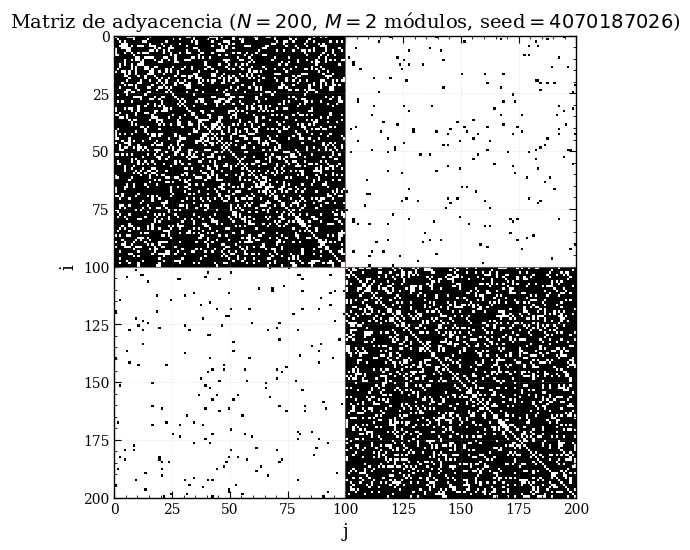

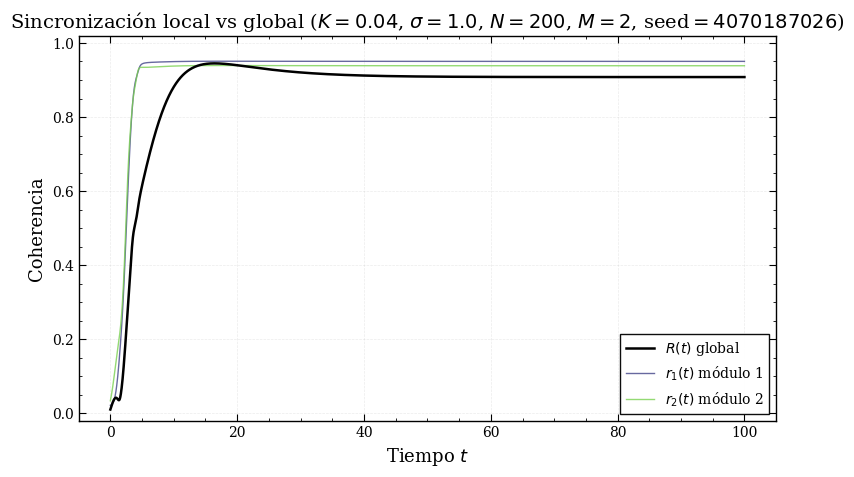


⟨R⟩ global    = 0.911
σ_R           = 0.005
⟨r_m⟩ módulos = [0.95  0.939]


In [9]:
N, n_modules = 200, 2
p_in, p_out  = 0.8, 0.02

# Seed automática: cada ejecución una red distinta, pero registrada
A, module_id, seed = construir_red_SBM(N, n_modules, p_in, p_out)
print(f"Red SBM generada con seed = {seed}")

stats = estadisticas_red(A, module_id)
print(f"Aristas totales : {stats['aristas_totales']}")
print(f"  intra-módulo  : {stats['aristas_intra']}")
print(f"  inter-módulo  : {stats['aristas_inter']}")
print(f"  ratio intra/inter : {stats['ratio_intra_inter']:.1f}")

visualizar_red(A, module_id, seed, guardar=True)

sigma = 1.0
dt    = 0.01
t_max = 100.0
K     = 0.04

sys = Simulacion_modular(A, module_id, K, sigma, dt, t_max, seed=seed)
plot_R_y_r_m_vs_t(sys, K, sigma, seed, guardar=True)

print(f"\n⟨R⟩ global    = {sys.R_mean:.3f}")
print(f"σ_R           = {sys.R_std:.3f}")
print(f"⟨r_m⟩ módulos = {np.array2string(sys.r_m_mean, precision=3)}")